In [3]:
import os
import re
import gzip
from pathlib import Path

import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
import anndata as ad
import scanpy as sc

os.chdir('c:\\Users\\ankit\\Documents\\scFM\\train_data\\GSE212837') 
base = Path("GSE212837/work")  # adjust if needed



In [4]:
from pathlib import Path
import re

import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
import anndata as ad

# point this to your flat directory
base = Path(r"C:/Users/ankit/Documents/scFM/train_data/GSE212837/work")

selected = {
    "GSM6556449": {"condition": "Control", "title": "Human Control Liver 1"},
    "GSM6556450": {"condition": "Control", "title": "Human Control Liver 2"},
    "GSM6556451": {"condition": "Control", "title": "Human Control Liver 3"},
    "GSM6556452": {"condition": "NASH",    "title": "Human NASH Liver 1 R1C1"},
    "GSM6556453": {"condition": "NASH",    "title": "Human NASH Liver 1 R1C2"},
    "GSM6556454": {"condition": "NASH",    "title": "Human NASH Liver 2 R1C1"},
    "GSM6556455": {"condition": "NASH",    "title": "Human NASH Liver 2 R2C1"},
    "GSM6556456": {"condition": "NASH",    "title": "Human NASH Liver 3 R4C1"},
    "GSM6556457": {"condition": "NASH",    "title": "Human NASH Liver 3 R5C2"},
    "GSM6556458": {"condition": "NASH",    "title": "Human NASH Liver 3 R6C1"},
    "GSM6556459": {"condition": "NASH",    "title": "Human NASH Liver 4 R4C1"},
    "GSM6556460": {"condition": "NASH",    "title": "Human NASH Liver 4 R6C1"},
    "GSM6556461": {"condition": "NASH",    "title": "Human NASH Liver 5 R3C8"},
    "GSM6556462": {"condition": "NASH",    "title": "Human NASH Liver 5 R5C5"},
    "GSM6556463": {"condition": "NASH",    "title": "Human NASH Liver 6"},
    "GSM6556464": {"condition": "NASH",    "title": "Human NASH Liver 7"},
    "GSM6556465": {"condition": "NASH",    "title": "Human NASH Liver 8"},
    "GSM6556466": {"condition": "NASH",    "title": "Human NASH Liver 9"},
}

def read_tsv(path):
    return pd.read_csv(path, sep="\t", header=None, compression="gzip")

def make_unique(vals):
    seen = {}
    out = []
    for v in vals:
        v = str(v)
        if v not in seen:
            seen[v] = 0
            out.append(v)
        else:
            seen[v] += 1
            out.append(f"{v}_{seen[v]}")
    return out

def files_for_gsm(gsm_id, base):
    barcodes = list(base.glob(f"{gsm_id}*_barcodes.tsv.gz"))
    features = list(base.glob(f"{gsm_id}*_features.tsv.gz"))
    matrix   = list(base.glob(f"{gsm_id}*_matrix.mtx.gz"))

    if len(barcodes) != 1 or len(features) != 1 or len(matrix) != 1:
        raise FileNotFoundError(
            f"{gsm_id}: expected 1 barcode, 1 features, 1 matrix file\n"
            f"barcodes={barcodes}\nfeatures={features}\nmatrix={matrix}"
        )
    return barcodes[0], features[0], matrix[0]

def read_one_sample(gsm_id):
    bc_file, feat_file, mtx_file = files_for_gsm(gsm_id, base)

    print(f"Reading {gsm_id}")
    print("  ", bc_file.name)
    print("  ", feat_file.name)
    print("  ", mtx_file.name)

    X = mmread(str(mtx_file)).tocsr()

    barcodes = read_tsv(bc_file).iloc[:, 0].astype(str).tolist()
    feats = read_tsv(feat_file)

    if feats.shape[1] == 1:
        gene_ids = feats.iloc[:, 0].astype(str)
        gene_symbols = feats.iloc[:, 0].astype(str)
        feature_type = pd.Series(["Gene Expression"] * len(feats))
    elif feats.shape[1] == 2:
        gene_ids = feats.iloc[:, 0].astype(str)
        gene_symbols = feats.iloc[:, 1].astype(str)
        feature_type = pd.Series(["Gene Expression"] * len(feats))
    else:
        gene_ids = feats.iloc[:, 0].astype(str)
        gene_symbols = feats.iloc[:, 1].astype(str)
        feature_type = feats.iloc[:, 2].astype(str)

    # 10x MTX is usually genes x cells, so transpose to cells x genes
    if X.shape == (len(gene_ids), len(barcodes)):
        X = X.T.tocsr()
    elif X.shape == (len(barcodes), len(gene_ids)):
        X = X.tocsr()
    else:
        raise ValueError(
            f"{gsm_id}: matrix shape {X.shape} does not match "
            f"{len(barcodes)} barcodes and {len(gene_ids)} genes"
        )

    sample_name = bc_file.name.replace("_barcodes.tsv.gz", "")

    obs = pd.DataFrame(index=[f"{sample_name}:{bc}" for bc in barcodes])
    obs["barcode"] = barcodes
    obs["gsm_id"] = gsm_id
    obs["sample_name"] = sample_name
    obs["sample_title"] = selected[gsm_id]["title"]
    obs["condition"] = selected[gsm_id]["condition"]

    # donor from title, e.g. Human NASH Liver 3 R4C1 -> donor 3
    m = re.search(r"Liver\s+(\d+)", selected[gsm_id]["title"])
    obs["donor"] = f"Human_Liver_{m.group(1)}" if m else gsm_id

    var = pd.DataFrame(index=make_unique(gene_symbols.fillna(gene_ids)))
    var["gene_id"] = gene_ids.values
    var["gene_symbol"] = gene_symbols.values
    var["feature_type"] = feature_type.values

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.layers["counts"] = adata.X.copy()
    return adata

adatas = [read_one_sample(gsm_id) for gsm_id in selected]

adata = ad.concat(
    adatas,
    axis=0,
    join="outer",
    merge="same",
    label="batch",
    keys=list(selected.keys()),
    index_unique=None,
    fill_value=0
)

adata.X = adata.X.tocsr()
adata.layers["counts"] = adata.layers["counts"].tocsr()

print(adata)
print("\nCondition counts:")
print(adata.obs["condition"].value_counts())

print("\nSamples:")
print(adata.obs["gsm_id"].value_counts().sort_index())

out = base / "GSE212837_human_NASH_control_raw.h5ad"
adata.write_h5ad(out, compression="gzip")
print(f"\nSaved to: {out}")

Reading GSM6556449
   GSM6556449_humanCTRL_1_barcodes.tsv.gz
   GSM6556449_humanCTRL_1_features.tsv.gz
   GSM6556449_humanCTRL_1_matrix.mtx.gz
Reading GSM6556450
   GSM6556450_humanCTRL_2_barcodes.tsv.gz
   GSM6556450_humanCTRL_2_features.tsv.gz
   GSM6556450_humanCTRL_2_matrix.mtx.gz
Reading GSM6556451
   GSM6556451_humanCTRL_3_barcodes.tsv.gz
   GSM6556451_humanCTRL_3_features.tsv.gz
   GSM6556451_humanCTRL_3_matrix.mtx.gz
Reading GSM6556452
   GSM6556452_humanNASH_1_40kNuclei_R1C1_DMSO_barcodes.tsv.gz
   GSM6556452_humanNASH_1_40kNuclei_R1C1_DMSO_features.tsv.gz
   GSM6556452_humanNASH_1_40kNuclei_R1C1_DMSO_matrix.mtx.gz
Reading GSM6556453
   GSM6556453_humanNASH_1_40kNuclei_R1C2_Flash_barcodes.tsv.gz
   GSM6556453_humanNASH_1_40kNuclei_R1C2_Flash_features.tsv.gz
   GSM6556453_humanNASH_1_40kNuclei_R1C2_Flash_matrix.mtx.gz
Reading GSM6556454
   GSM6556454_humanNASH_2_R1C1_30kNuclei_barcodes.tsv.gz
   GSM6556454_humanNASH_2_R1C1_30kNuclei_features.tsv.gz
   GSM6556454_humanNASH_2_R1C

Read in saved adata

In [15]:
import scanpy as sc

adata = sc.read_h5ad(r"C:/Users/ankit/Documents/scFM/train_data/GSE212837/work/GSE212837_human_NASH_control_raw.h5ad")
print(adata)
print(adata.obs["condition"].value_counts())
print(adata.obs["gsm_id"].value_counts().sort_index())
print("counts layer present:", "counts" in adata.layers)

AnnData object with n_obs × n_vars = 252669 × 36601
    obs: 'barcode', 'gsm_id', 'sample_name', 'sample_title', 'condition', 'donor', 'batch'
    var: 'gene_id', 'gene_symbol', 'feature_type'
    layers: 'counts'
condition
NASH       169244
Control     83425
Name: count, dtype: int64
gsm_id
GSM6556449    49166
GSM6556450    15494
GSM6556451    18765
GSM6556452    11712
GSM6556453    18022
GSM6556454     6121
GSM6556455     6768
GSM6556456     4540
GSM6556457     5917
GSM6556458     6957
GSM6556459     3788
GSM6556460     3879
GSM6556461     5885
GSM6556462     6660
GSM6556463    40950
GSM6556464    11586
GSM6556465    16792
GSM6556466    19667
Name: count, dtype: int64
counts layer present: True


In [ ]:
# View unique gsm titles
print(adata.obs["gsm_id"].unique())

['GSM6556449', 'GSM6556450', 'GSM6556451', 'GSM6556452', 'GSM6556453', ..., 'GSM6556462', 'GSM6556463', 'GSM6556464', 'GSM6556465', 'GSM6556466']
Length: 18
Categories (18, object): ['GSM6556449', 'GSM6556450', 'GSM6556451', 'GSM6556452', ..., 'GSM6556463', 'GSM6556464', 'GSM6556465', 'GSM6556466']


In [11]:
import pandas as pd

meta = pd.read_csv("meta_manual.csv")
print(meta.head())

       Sample Sex  Age  Disease New_Sample_ID  Patient_ID
0  GSM6556449   F   63  Control  GSM6556449.1  GSM6556449
1  GSM6556450   F   51  Control  GSM6556450.1  GSM6556450
2  GSM6556451   M   69  Control  GSM6556451.1  GSM6556451
3  GSM6556452   M   34     NASH  GSM6556452.1  GSM6556452
4  GSM6556453   M   34     NASH  GSM6556452.2  GSM6556452


In [17]:
import pandas as pd

# Read the metadata
meta = pd.read_csv("meta_manual.csv")

# Merge metadata with adata.obs based on gsm_id
# First, ensure the merge column has the same name
meta_renamed = meta.rename(columns={'Sample': 'gsm_id'})

# Merge the dataframes
adata.obs = adata.obs.merge(
    meta_renamed[['gsm_id', 'Sex', 'Age', 'New_Sample_ID', 'Patient_ID']], 
    on='gsm_id', 
    how='left'
)

# Verify the new columns were added
print(adata.obs.columns)
print(adata.obs[['gsm_id', 'Sex', 'Age', 'Patient_ID']].head())

Index(['barcode', 'gsm_id', 'sample_name', 'sample_title', 'condition',
       'donor', 'batch', 'Sex', 'Age', 'New_Sample_ID', 'Patient_ID'],
      dtype='object')
       gsm_id Sex  Age  Patient_ID
0  GSM6556449   F   63  GSM6556449
1  GSM6556449   F   63  GSM6556449
2  GSM6556449   F   63  GSM6556449
3  GSM6556449   F   63  GSM6556449
4  GSM6556449   F   63  GSM6556449


c:\Users\ankit\miniconda3\envs\scanpy\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [6]:
# save
adata.write_h5ad(r"C:/Users/ankit/Documents/scFM/train_data/GSE212837/work/GSE212837_human_NASH_control_raw_with_meta.h5ad", compression="gzip")

In [4]:
# Read in the new file to verify
adata = sc.read_h5ad(r"C:/Users/ankit/Documents/scFM/train_data/GSE212837/work/GSE212837_human_NASH_control_raw_with_meta.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 252669 × 36601
    obs: 'barcode', 'gsm_id', 'sample_name', 'sample_title', 'condition', 'donor', 'batch', 'Sex', 'Age', 'New_Sample_ID', 'Patient_ID'
    var: 'gene_id', 'gene_symbol', 'feature_type'
    layers: 'counts'


In [5]:
# Add assay type column to obs
adata.obs["assay_type"] = "snRNA-seq"
print(adata.obs["assay_type"].value_counts())

assay_type
snRNA-seq    252669
Name: count, dtype: int64


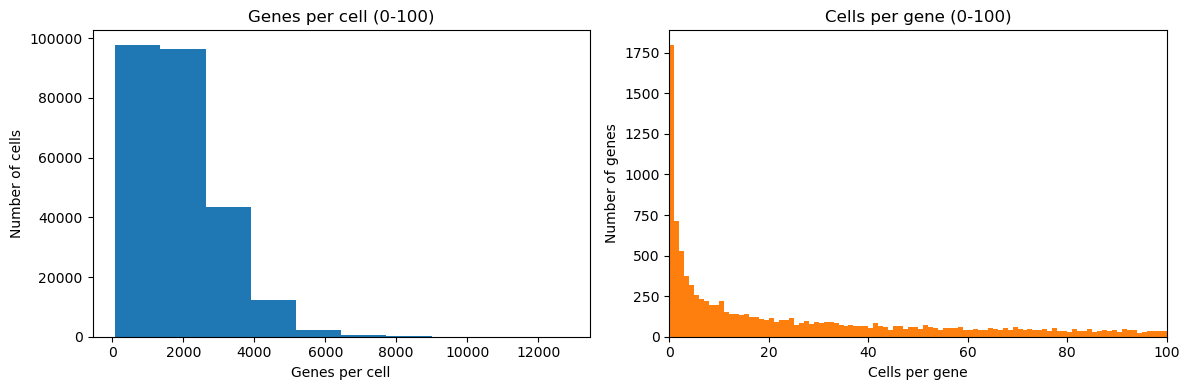

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [8]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell >= min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 75
Number of cells with at least 75 genes: 252669
